# MNIST: SVD Optimizer Analysis

Analysis of SVD optimizer (with RMSprop) vs standard optimizers on MNIST classification.
Includes analysis of the `variable_k` setting.

## 1. Setup & Data Loading

In [21]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/mnist_labelRegression')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/mnist_labelRegression


In [22]:
# Load JSONL results
from style import load_results

def sel_fn(fname):
    return "mseed6310" in fname

df = load_results("mnist_scan_labelRegression", selection_fn=sel_fn)
print(f"Total: {len(df)} experiment runs")
print(f"Optimizers: {sorted(df['optimizer'].unique())}")
print(f"Batch sizes: {sorted(df['batch_size'].unique())}")

def is_bad(row):
    if np.isnan(row['losses']['val'][-1]):
        return True
    return False
df['is_bad'] = df.apply(is_bad, axis=1)
df = df[~df['is_bad']]
print(f"After removing bad runs: {len(df)} experiment runs")

Loaded 179 runs from ../experiment_results/mnist_scan_labelRegression/ (directory format)
Total: 179 experiment runs
Optimizers: ['Adam', 'HIG', 'JD_UPGrad', 'LBFGS', 'PolyakSGD', 'RMSprop', 'SGD', 'SVD']
Batch sizes: [np.int64(64)]
After removing bad runs: 161 experiment runs


In [23]:
for opt in df.optimizer.unique():
    for seed in df.model_seed.unique():
        N = len(df[(df.model_seed == seed) & (df.optimizer == opt)])
        print(f"Seed {seed}: {N} {opt} runs")

Seed 6310: 8 HIG runs
Seed 6310: 4 JD_UPGrad runs
Seed 6310: 4 Adam runs
Seed 6310: 4 RMSprop runs
Seed 6310: 4 SGD runs
Seed 6310: 8 LBFGS runs
Seed 6310: 1 PolyakSGD runs
Seed 6310: 128 SVD runs


In [25]:
SEED_SEL = 6310
BASELINE_OPT = ['SGD','PolyakSGD','RMSprop','Adam','LBFGS','JD_UPGrad','HIG']
#BASELINE_OPT = ['SGD','RMSprop','Adam','LBFGS','JD_UPGrad','HIG']
df = df[df.model_seed == SEED_SEL]

In [26]:
# Helper functions
def get_final_loss(row, loss_type='val'):
    losses = row['losses'][loss_type]
    # Return last non-NaN value (handles instability)
    for val in reversed(losses):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            return val
    return np.nan

def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    return np.array(row['losses'].get(acc_type, []))

def sliding_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Add derived columns once on the full df
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df['final_val_acc'] = df.apply(lambda r: r['losses'].get('val_acc', [np.nan])[-1], axis=1)
df['final_train_acc'] = df.apply(lambda r: r['losses'].get('train_acc', [np.nan])[-1], axis=1)
df['total_time'] = df['losses'].apply(lambda l: l.get('total_time', np.nan))
df['avg_epoch_time'] = df['losses'].apply(lambda l: l.get('avg_epoch_time', np.nan))
df['avg_batch_time_train'] = df['losses'].apply(lambda l: l.get('avg_batch_time_train', np.nan))

def _time_excl_first(row):
    et = row['losses'].get('epoch_times', [])
    return sum(et[1:]) if len(et) > 1 else np.nan

def _avg_batch_excl_first(row):
    bt = row['losses'].get('batch_times_train', [])
    return np.mean(bt[1:]) if len(bt) > 1 else np.nan

df['time_excl_first_epoch'] = df.apply(_time_excl_first, axis=1)
df['avg_batch_time_excl_first'] = df.apply(_avg_batch_excl_first, axis=1)

batch_sizes = sorted(df['batch_size'].unique())
print(f"Available batch sizes: {batch_sizes}")

df_svd = df[(df['optimizer'] == 'SVD')].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

bs = sorted(df['batch_size'].unique())[0] 
batch_sizes = sorted(df['batch_size'].unique())
baseline_optimizers = sorted(df_baseline['optimizer'].unique().tolist())
k_fractions = sorted(df_svd['k_fraction'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
svd_rtols = sorted(df_svd['rtol'].dropna().unique())

print(f"\nSVD: {len(df_svd)} runs")
print(f"  k_fractions: {k_fractions}")
print(f"  lrs: {svd_lrs}")
print(f"  rtols: {svd_rtols}")
print(f"\nBaseline: {len(df_baseline)} runs")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  lrs: {sorted([l for l in df_baseline['lr'].unique() if l is not None])}")

Available batch sizes: [np.int64(64)]

SVD: 128 runs
  k_fractions: [np.float64(0.015625), np.float64(0.03125), np.float64(0.0625), np.float64(0.125), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  lrs: [np.float64(0.05), np.float64(0.1), np.float64(0.5), np.float64(1.0)]
  rtols: [np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.1)]

Baseline: 33 runs
  Optimizers: ['Adam', 'HIG', 'JD_UPGrad', 'LBFGS', 'PolyakSGD', 'RMSprop', 'SGD']
  lrs: [np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.5), np.float64(nan)]


# Custom plots

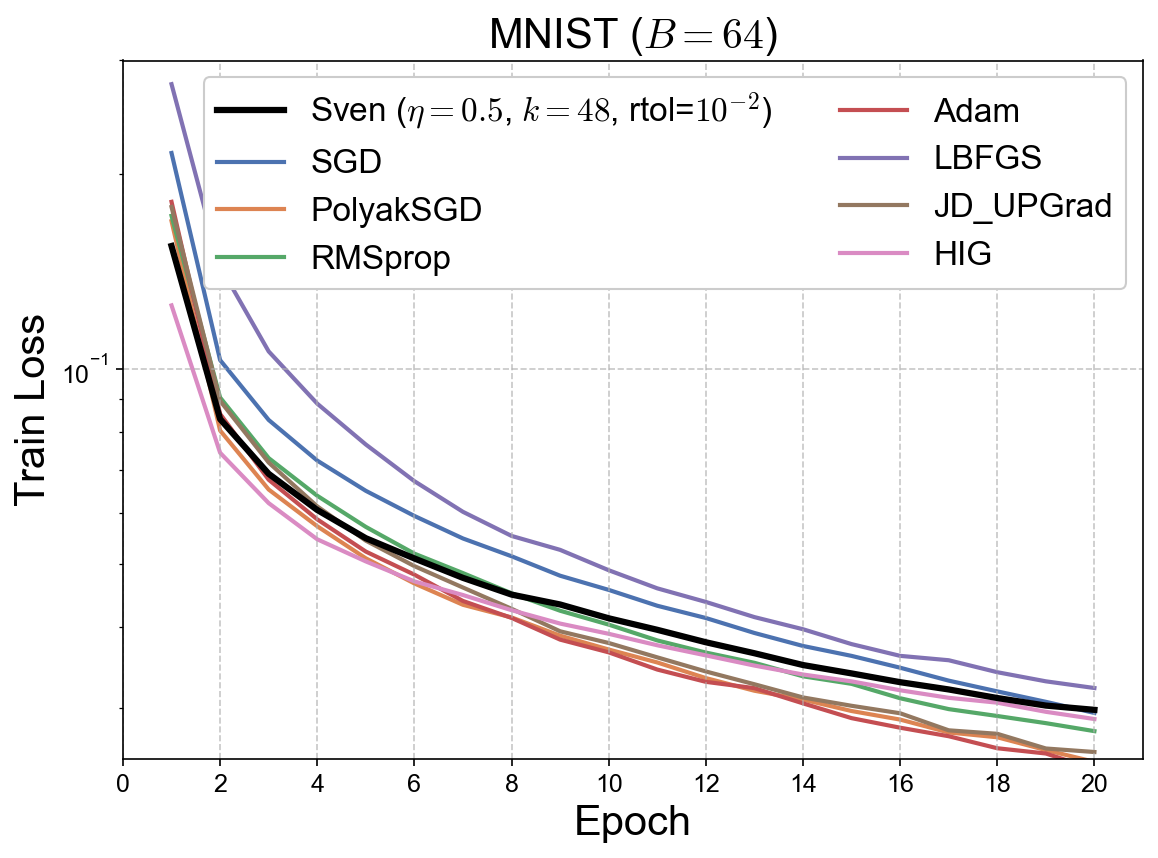

In [27]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD
best_svd_row = df_svd.loc[df_svd[df_svd['batch_size'] == bs]['final_val_loss'].idxmin()]
train_curve = get_loss_curve(best_svd_row, 'train')
n_epochs = len(train_curve)
epochs_train = np.arange(1,n_epochs + 1)

ax.plot(epochs_train, train_curve, color='k', linewidth=3, label=f"Sven ($\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)",zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df_baseline.loc[opt_df['final_val_loss'].idxmin()]
    label = f"{opt}"
    ax.plot(epochs_train, get_loss_curve(best_row, 'train'), color=colors[i], linewidth=2, label=label,zorder=1)

ax.set_xlabel('Epoch',fontsize=20)
ax.set_ylabel('Train Loss',fontsize=20)
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1,fontsize=16)
ax.set_title(f"MNIST ($B = {bs}$)",fontsize=20)
plt.ylim([2.5e-2,0.3])
plt.xlim(0,n_epochs+1)
plt.xticks(np.arange(0, n_epochs+1, max(1, n_epochs//10)))
plt.grid(axis='both', linestyle='--', alpha=0.7,zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_loss_best.pdf')
plt.show()

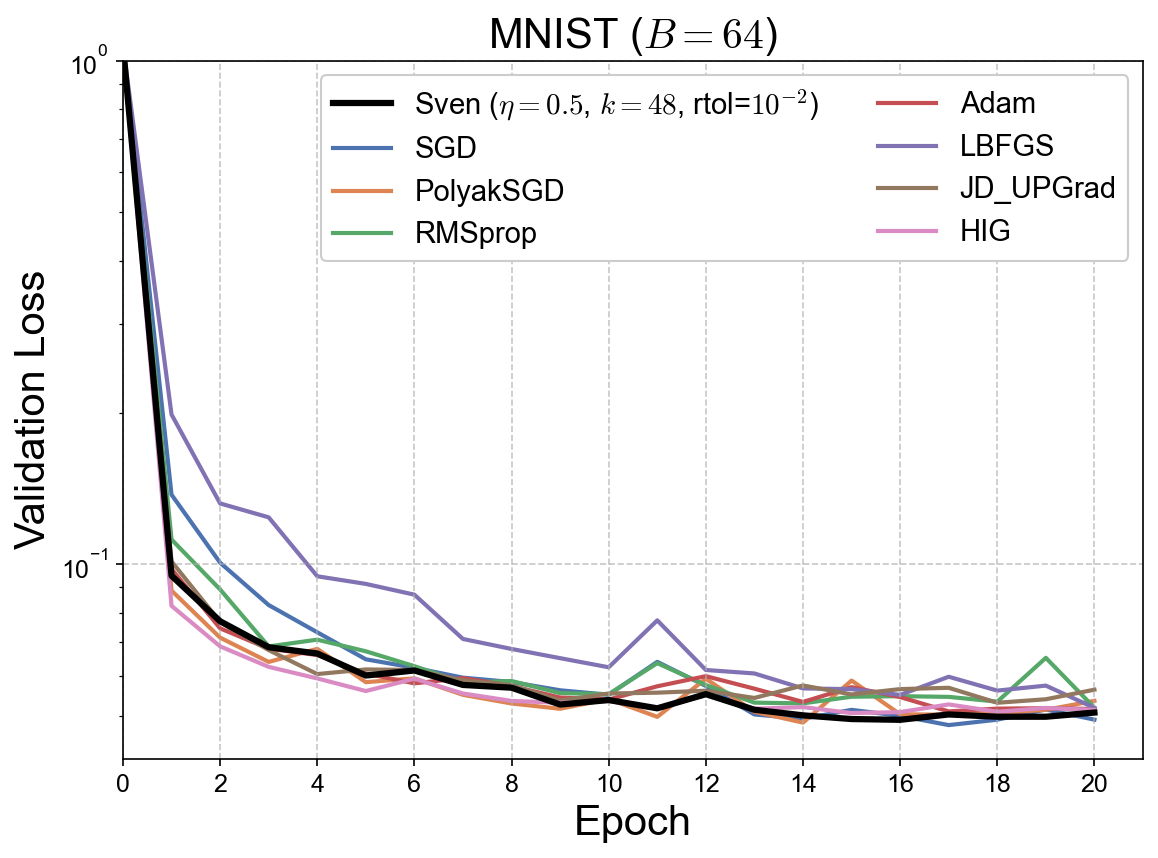

In [28]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD
best_svd_row = df_svd.loc[df_svd[df_svd['batch_size'] == bs]['final_val_loss'].idxmin()]
train_curve = get_loss_curve(best_svd_row, 'val')
n_epochs = len(train_curve)
epochs_train = np.arange(n_epochs)

ax.plot(epochs_train, train_curve, color='k', linewidth=3, label=f"Sven ($\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)",zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df_baseline.loc[opt_df['final_val_loss'].idxmin()]
    label= f"{opt}"
    ax.plot(epochs_train, get_loss_curve(best_row, 'val'), color=colors[i], linewidth=2, label=label,zorder=1)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"MNIST ($B = {bs}$)")
plt.ylim([None,1])
plt.xlim(0,n_epochs)
plt.xticks(np.arange(0, n_epochs+1, max(1, n_epochs//10)))
plt.grid(axis='both', linestyle='--', alpha=0.7,zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'val_loss_best.pdf')
plt.show()

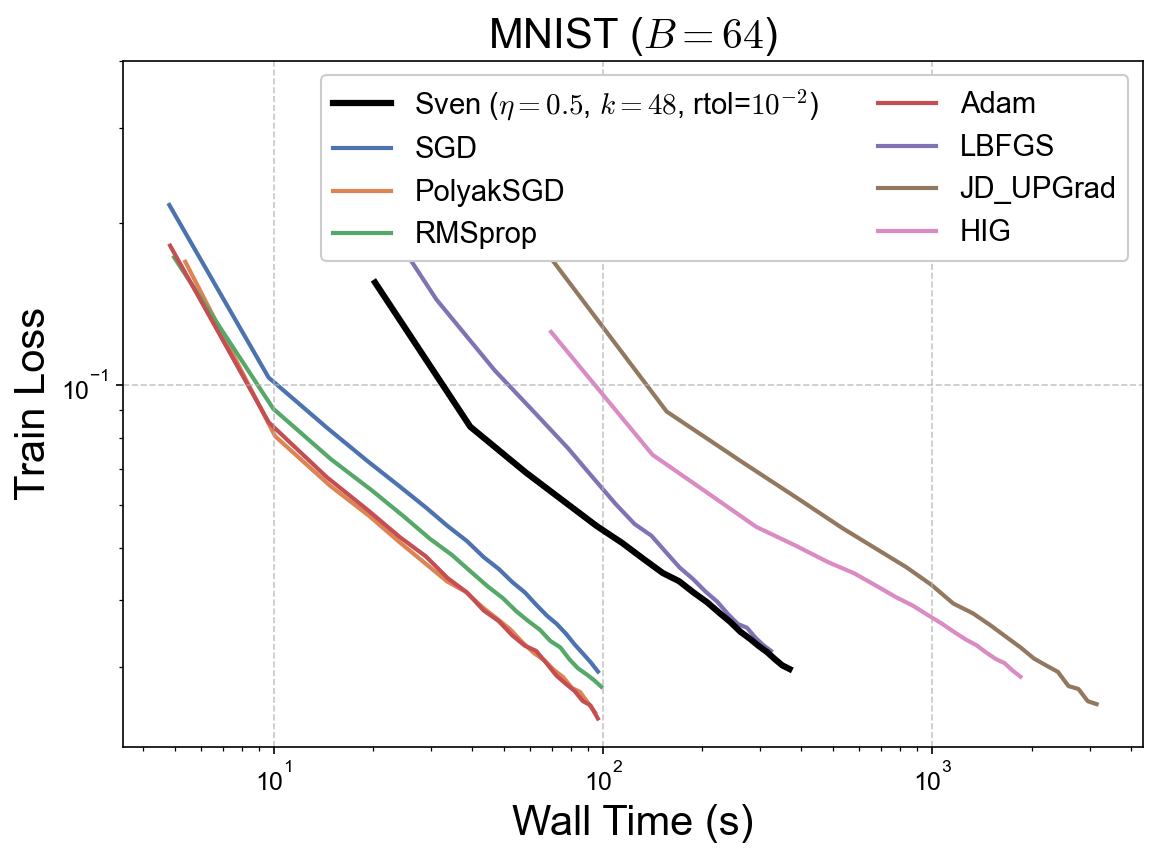

In [29]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD
best_svd_row = df_svd.loc[df_svd[df_svd['batch_size'] == bs]['final_val_loss'].idxmin()]
train_curve = get_loss_curve(best_svd_row, 'train')
wall_times = get_loss_curve(best_svd_row, 'epoch_times')
t = np.cumsum(wall_times)

ax.plot(t, train_curve, color='k', linewidth=3, label=f"Sven ($\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)",zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df_baseline.loc[opt_df['final_val_loss'].idxmin()]
    t = get_loss_curve(best_row, 'epoch_times')
    t = np.cumsum(t)
    label = f"{opt}"
    ax.plot(t, get_loss_curve(best_row, 'train'), color=colors[i], linewidth=2, label=label,zorder=1)

ax.set_xlabel('Wall Time (s)')
ax.set_ylabel('Train Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"MNIST ($B = {bs}$)")
plt.ylim([None,0.4])
#plt.xlim([1,None])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7,zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_train_loss_best.pdf')
plt.show()

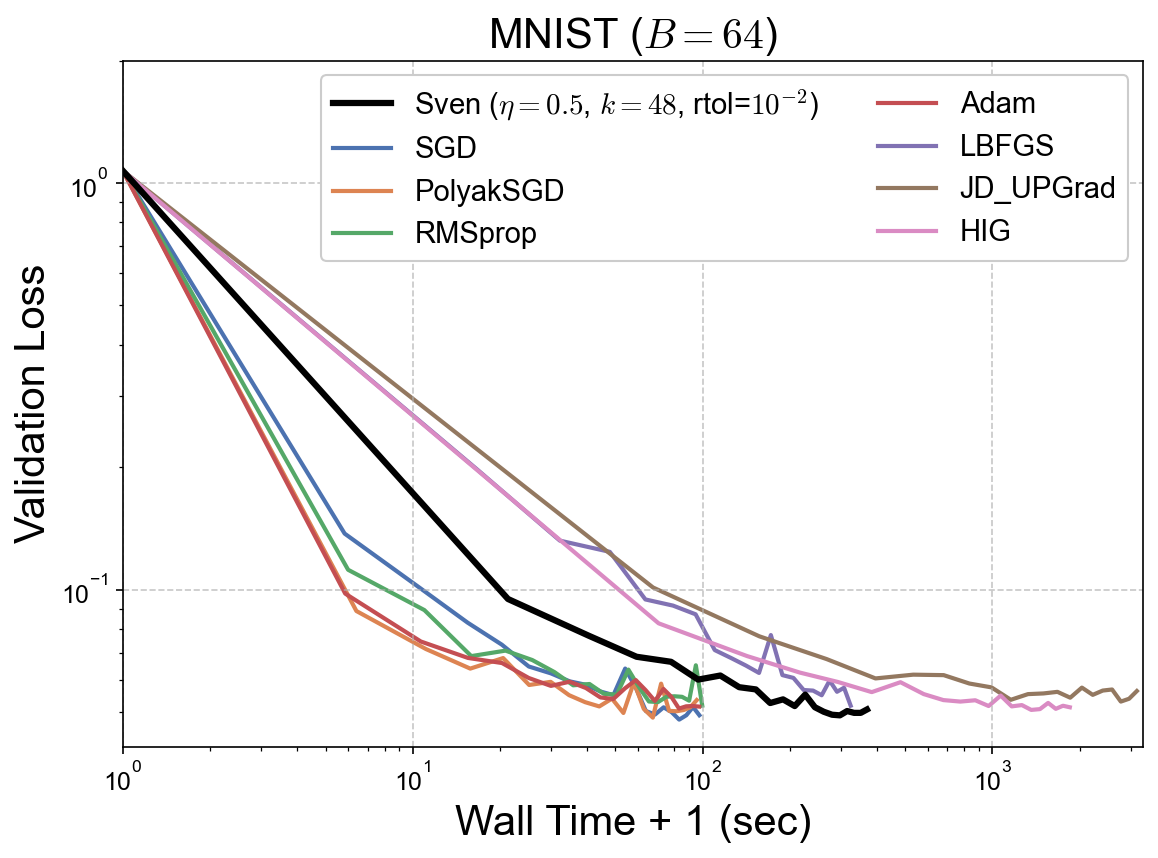

In [30]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []

# Best SVD
best_svd_row = df_svd.loc[df_svd[df_svd['batch_size'] == bs]['final_val_loss'].idxmin()]
train_curve = get_loss_curve(best_svd_row, 'val')
wall_times = get_loss_curve(best_svd_row, 'epoch_times')
wall_times = np.concatenate(([1], wall_times))  # Add 0 at start to align with epochs
t = np.cumsum(wall_times)

ax.plot(t, train_curve, color='k', linewidth=3, label=f"Sven ($\eta={best_svd_row['lr']}$, $k={int(best_svd_row['k'])}$, rtol=${lr_labels[best_svd_row['rtol']]}$)",zorder=2)

# Best baselines
for i, opt in enumerate(BASELINE_OPT):
    opt_df = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['batch_size'] == bs)]
    best_row = df_baseline.loc[opt_df['final_val_loss'].idxmin()]
    t = get_loss_curve(best_row, 'epoch_times')
    t = np.concatenate(([1], t))  # Add 0 at start to align with epochs
    t = np.cumsum(t)
    #label=f"{opt} ($\eta={lr_labels[best_row['lr']]}$)"
    label = f"{opt}"
    ax.plot(t, get_loss_curve(best_row, 'val'), color=colors[i], linewidth=2, label=label,zorder=1)

ax.set_xlabel('Wall Time + 1 (sec)')
ax.set_ylabel('Validation Loss')
ax.set_yscale('log')
plt.legend(ncol=2,loc='upper right',frameon=True,framealpha=1)
ax.set_title(f"MNIST ($B = {bs}$)")
plt.ylim([None,2])
#plt.yticks([1e-1])
plt.xlim([1,None])
plt.xscale('log')
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'wall_time_vs_val_loss_best.pdf')
plt.show()

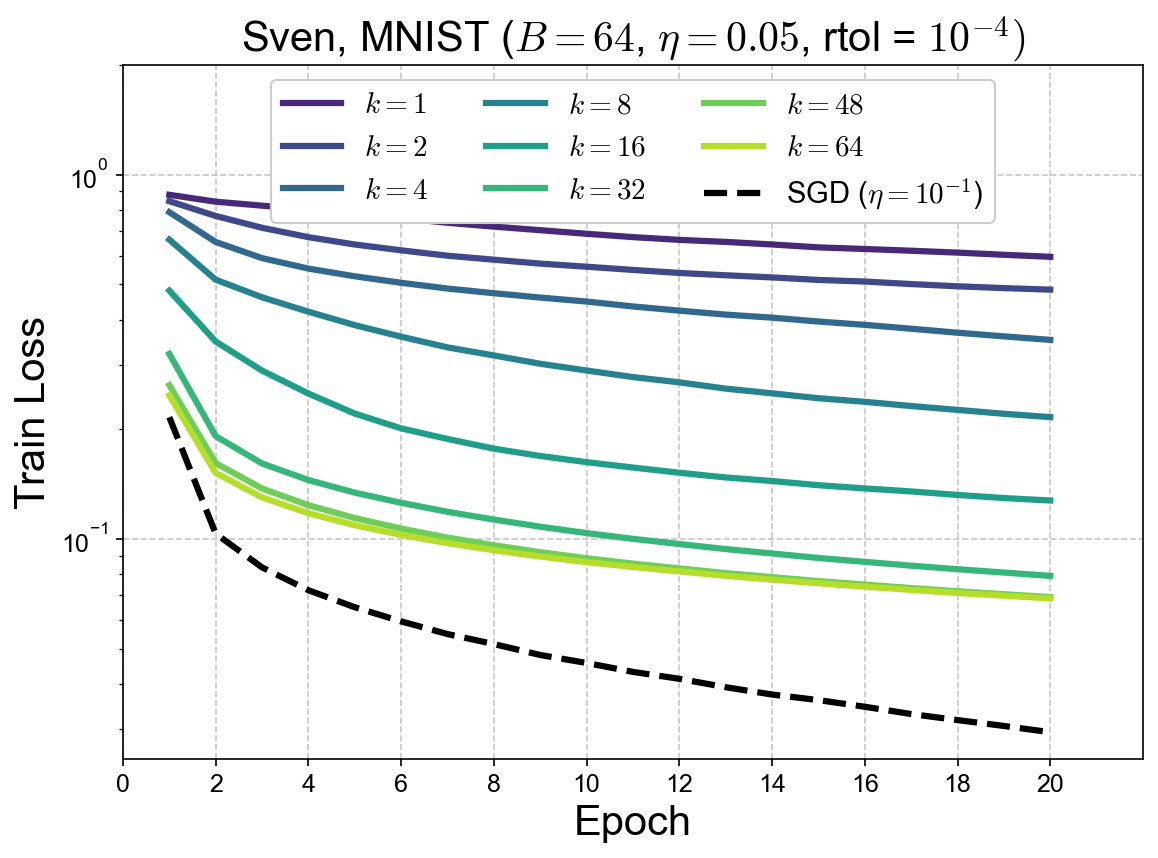

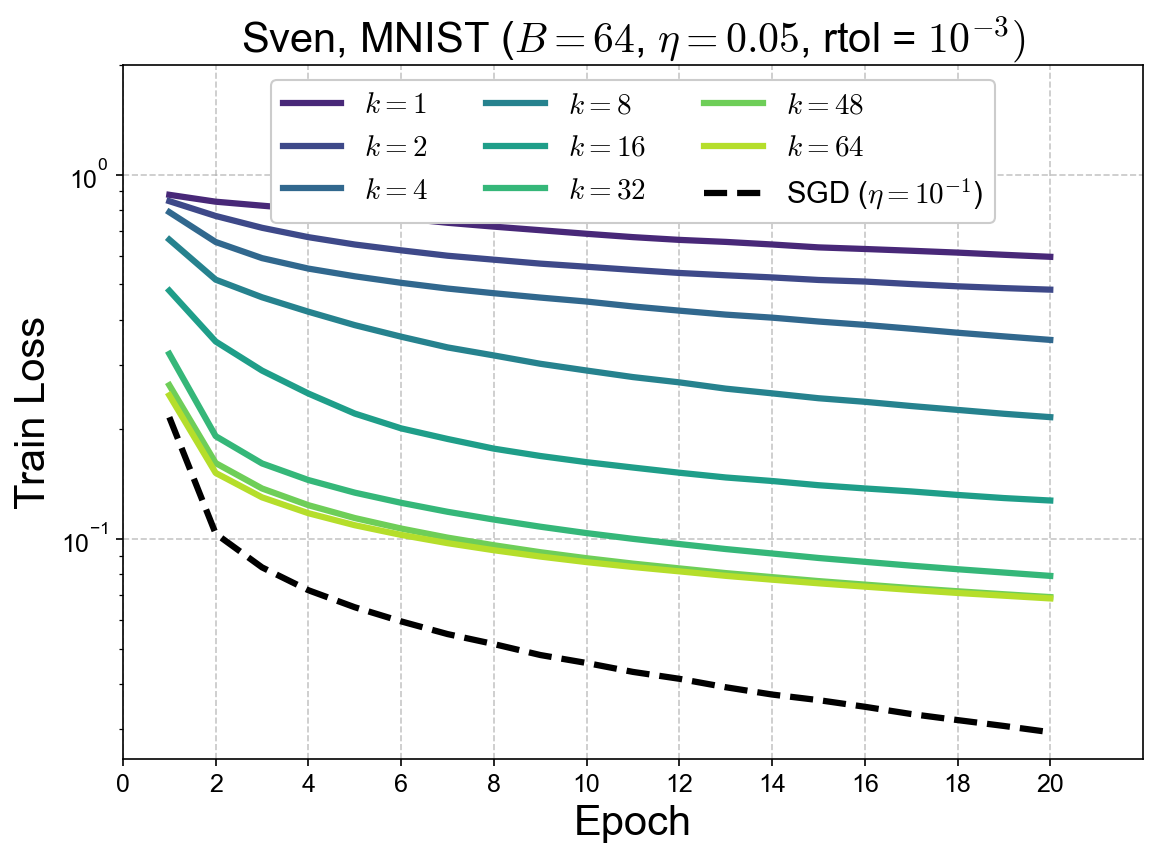

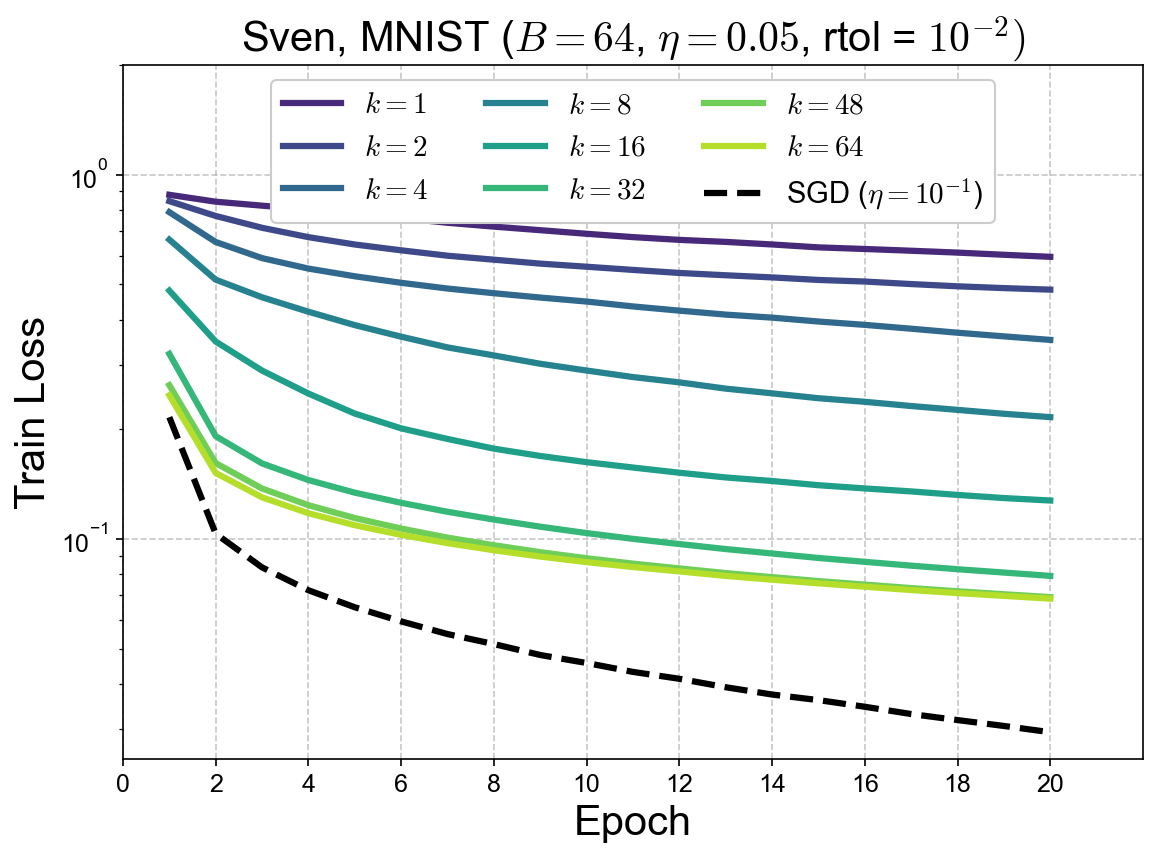

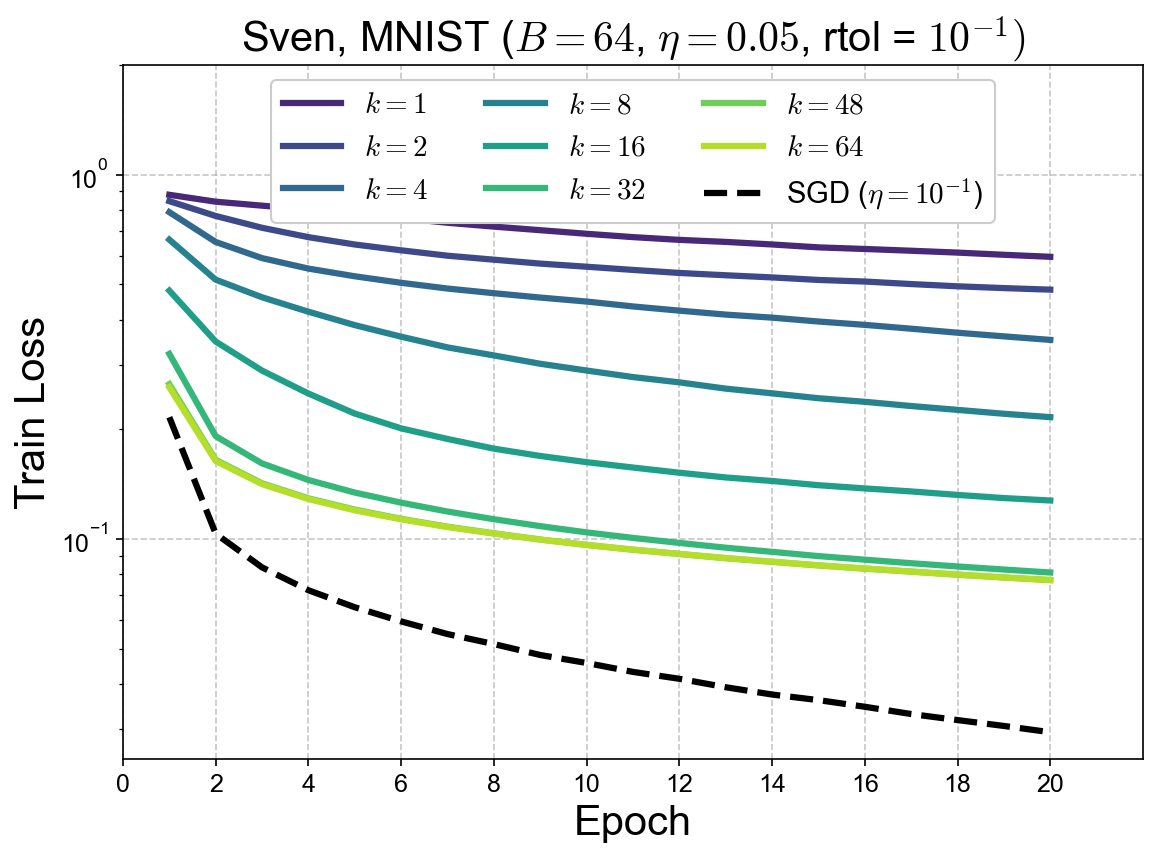

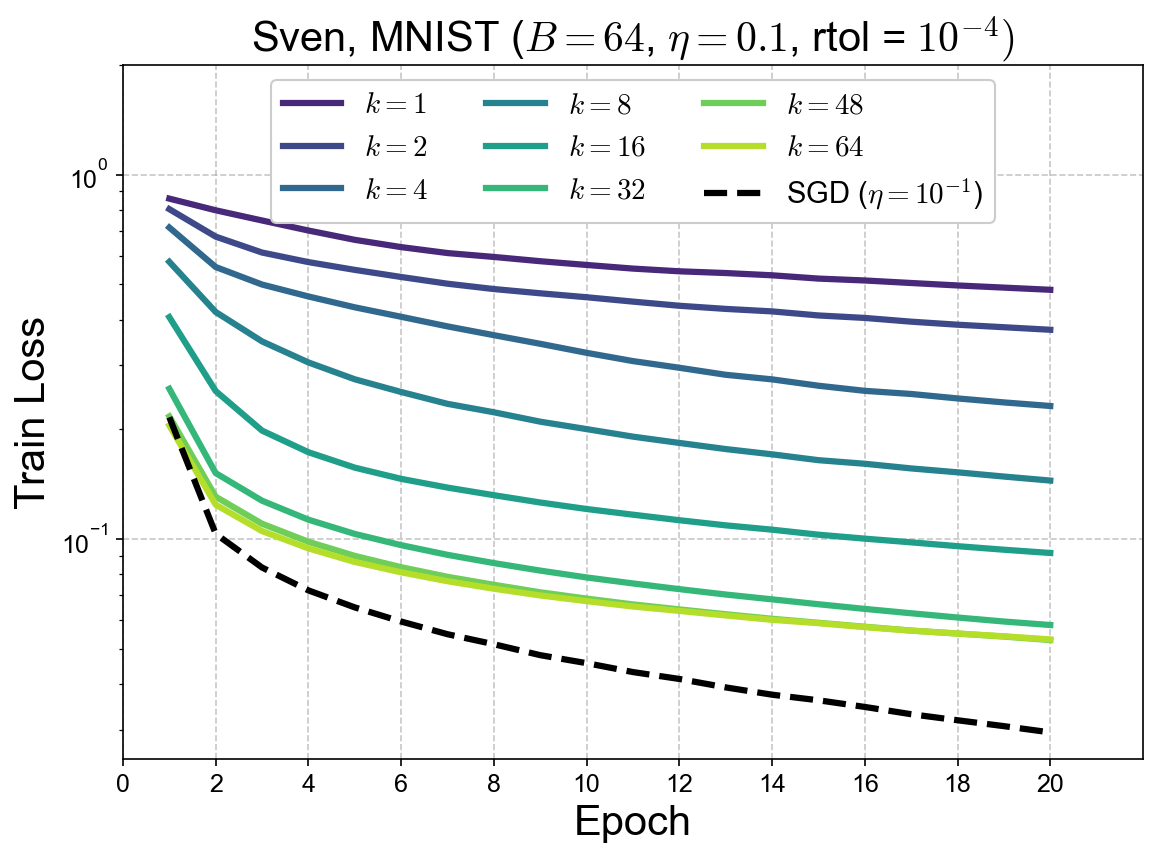

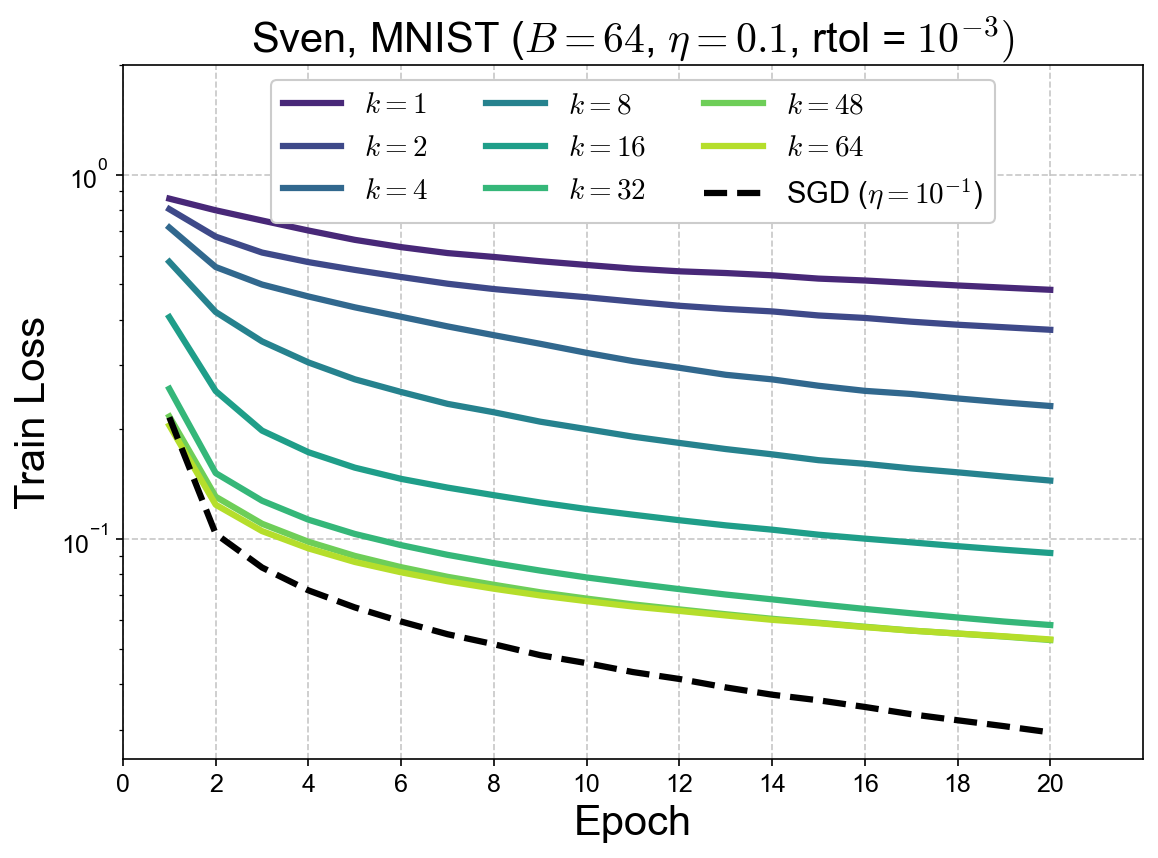

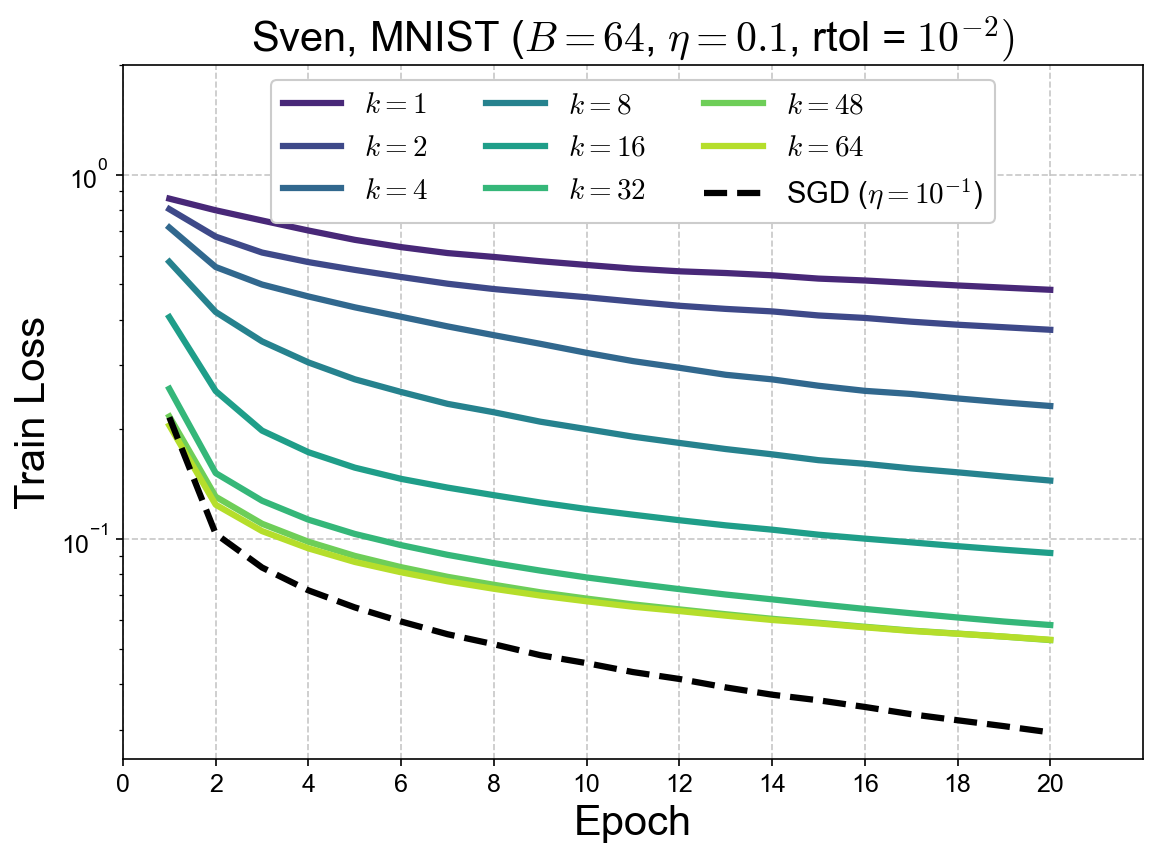

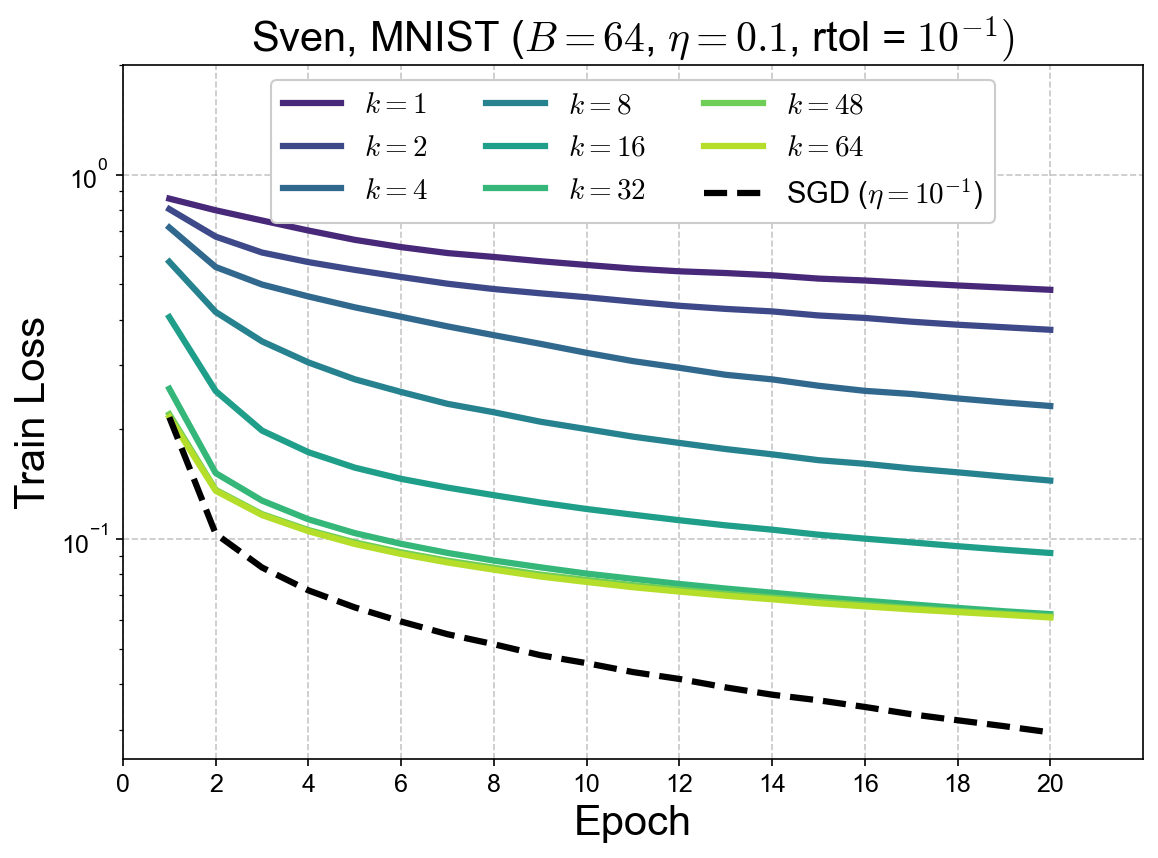

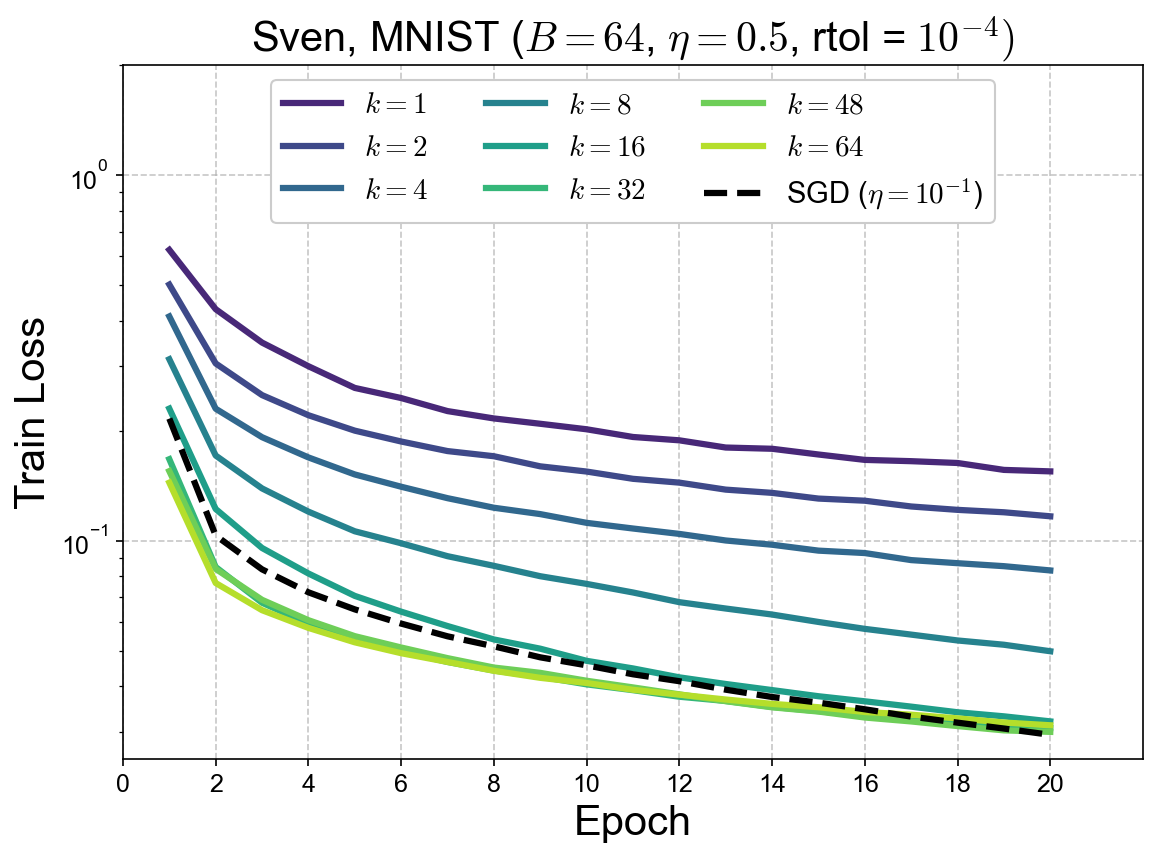

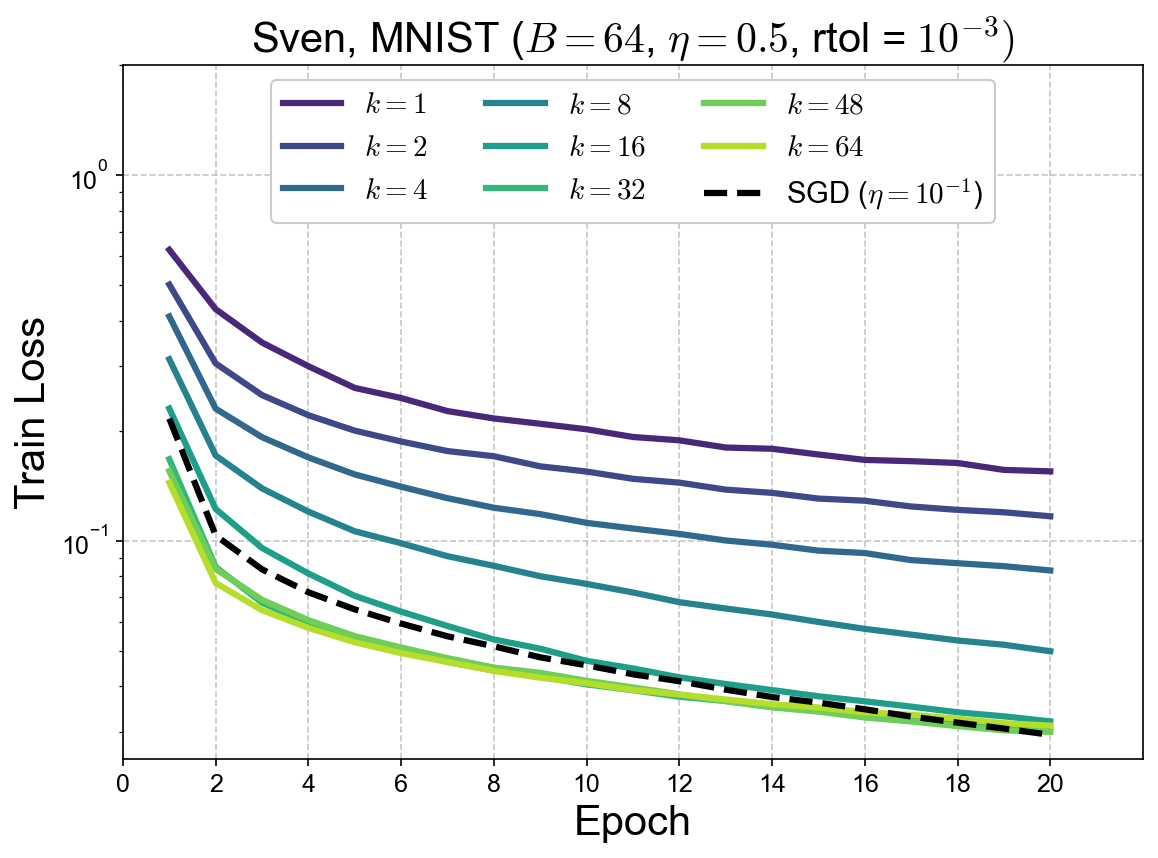

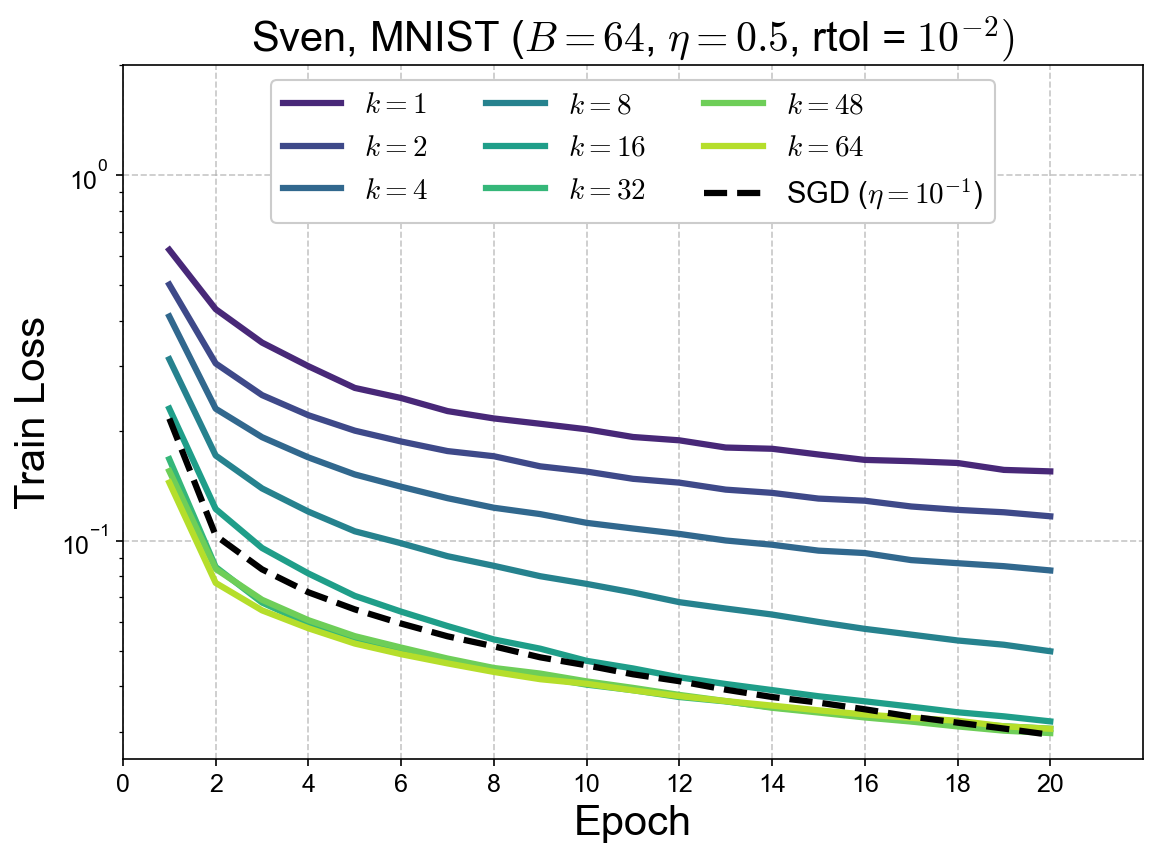

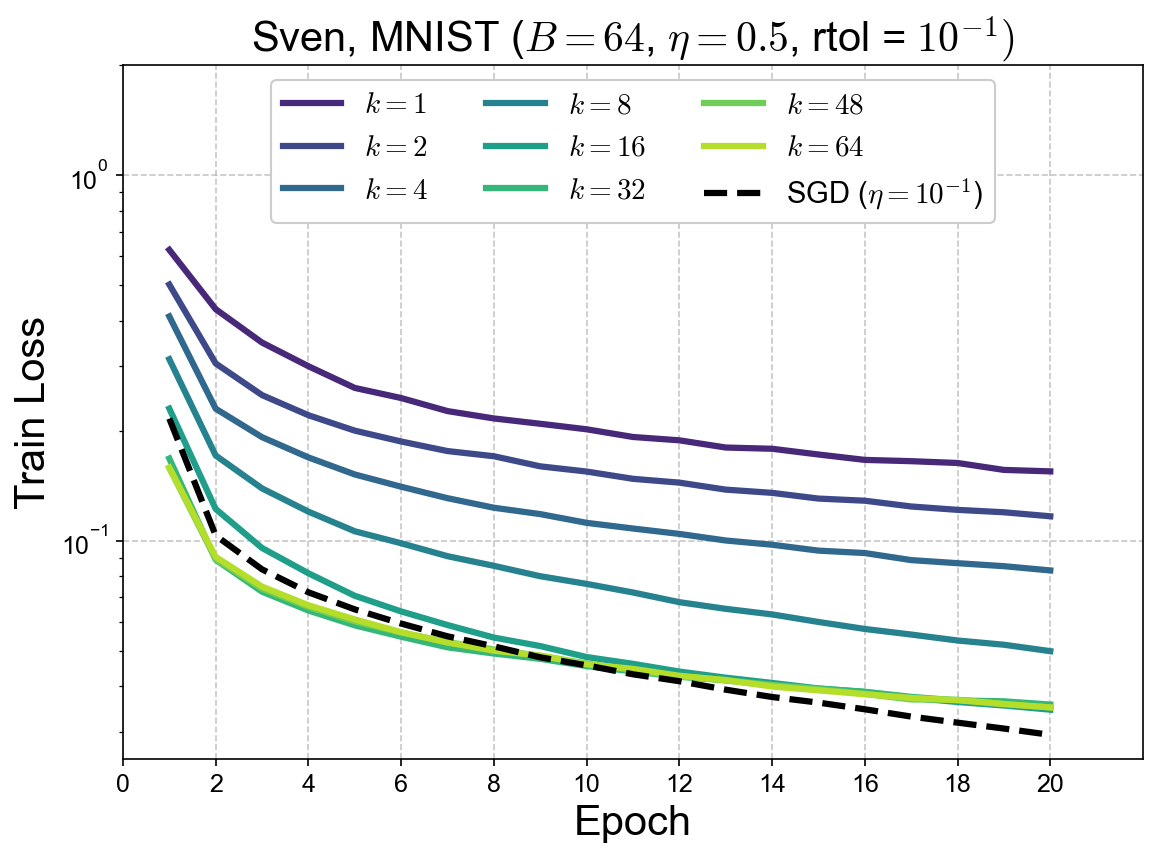

In [31]:
for LR in [0.05,0.1,0.5]:
    for RTOL in [1e-4,1e-3,1e-2,1e-1]:
        fig, ax = plt.subplots(figsize=(8, 6))
        df_sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        k_values = sorted(df_sel['k'].unique())
        colors = sns.color_palette("viridis",n_colors=len(k_values))
        for i,k in enumerate(k_values):
            row = df_sel[df_sel['k'] == k]
            assert len(row) == 1, f"Expected exactly one run for k={k}, found {len(row)}"
            row = row.iloc[0]
            train_curve = get_loss_curve(row, 'train')
            epochs = np.arange(1, len(train_curve) + 1)
            ax.plot(epochs, train_curve, label=f"$k={int(k)}$", color=colors[i], linewidth=3)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        best_sgd_row = df.loc[df_sgd['final_val_loss'].idxmin()]
        ax.plot(epochs, get_loss_curve(best_sgd_row, 'train'), label=f"SGD ($\eta={lr_labels[best_sgd_row['lr']]}$)", color='k', linestyle='--', linewidth=3)
    
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Train Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3,loc='upper center',frameon=True,framealpha=1)
        ax.set_title(f"Sven, MNIST ($B = {bs}$, $\eta={LR}$, rtol = ${lr_labels[RTOL]})$")
        plt.ylim([None,2])
        plt.xlim(0,n_epochs+1)
        plt.xticks(np.arange(0, n_epochs+1, max(1, n_epochs//10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"train_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()

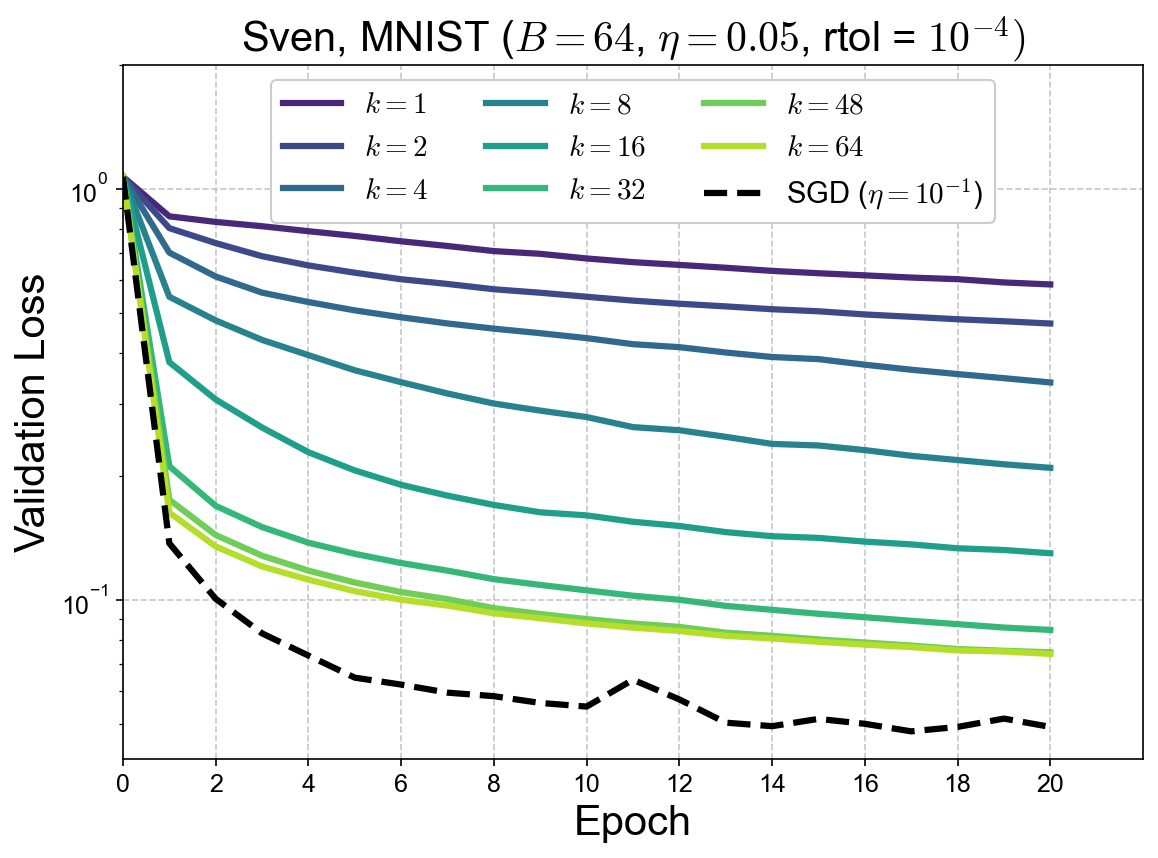

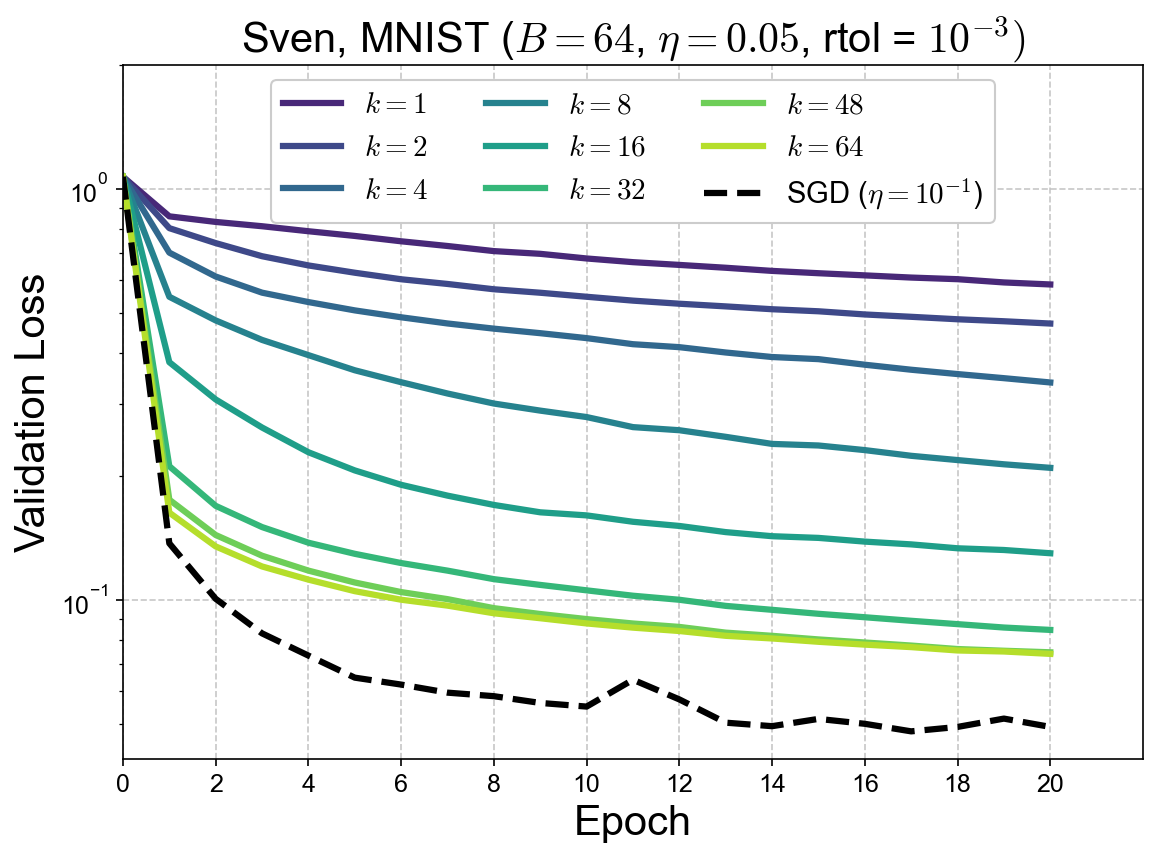

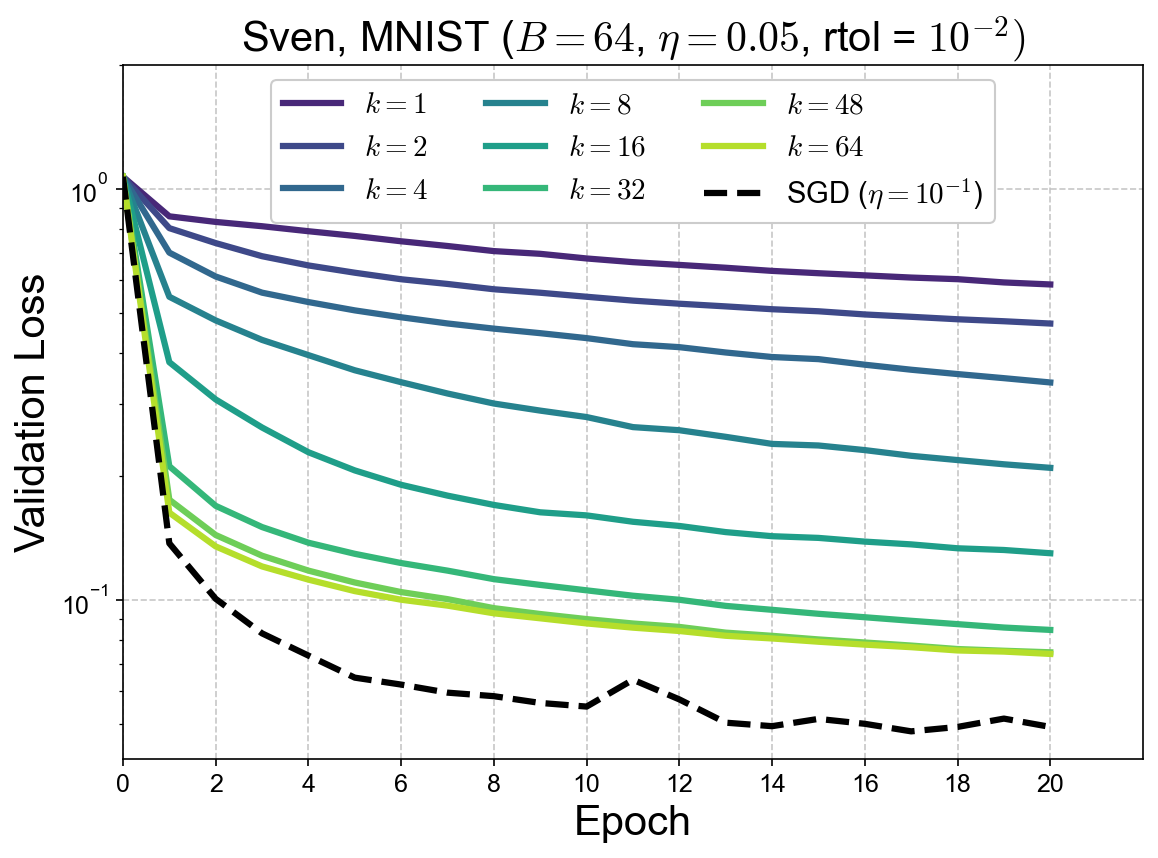

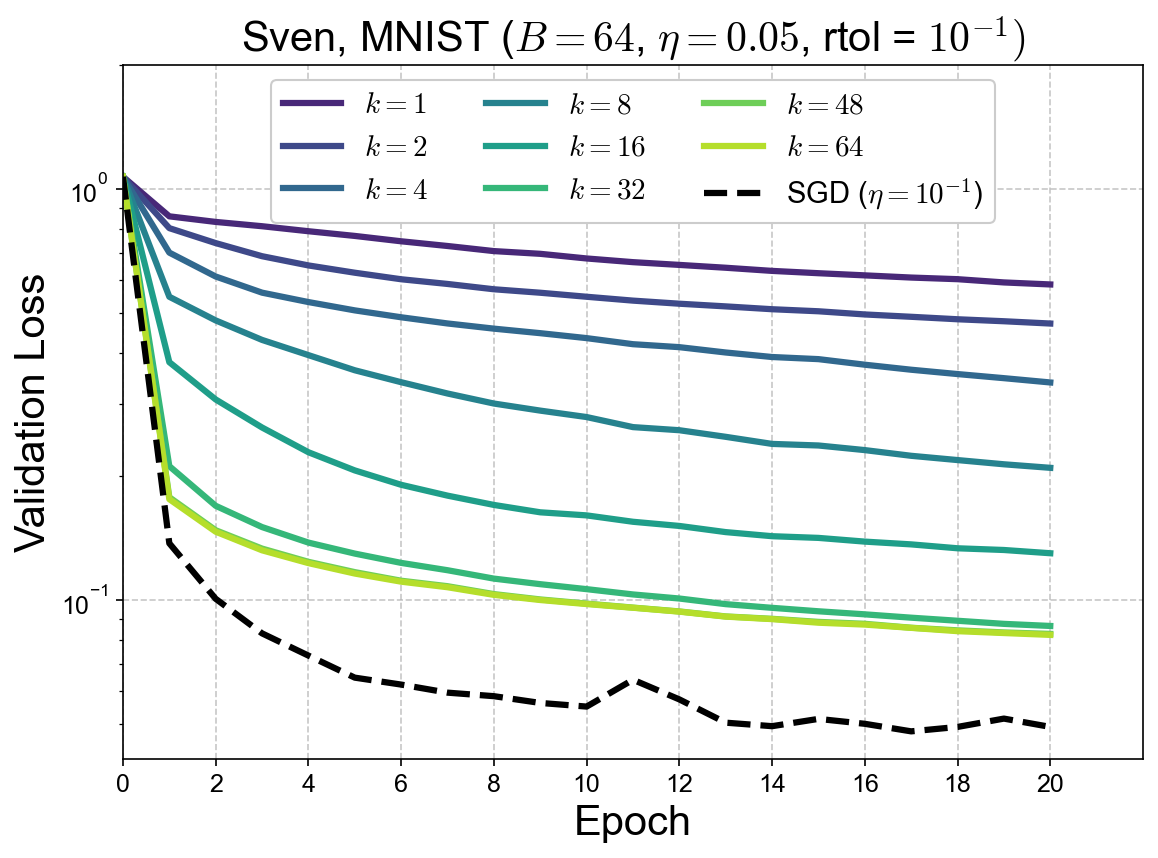

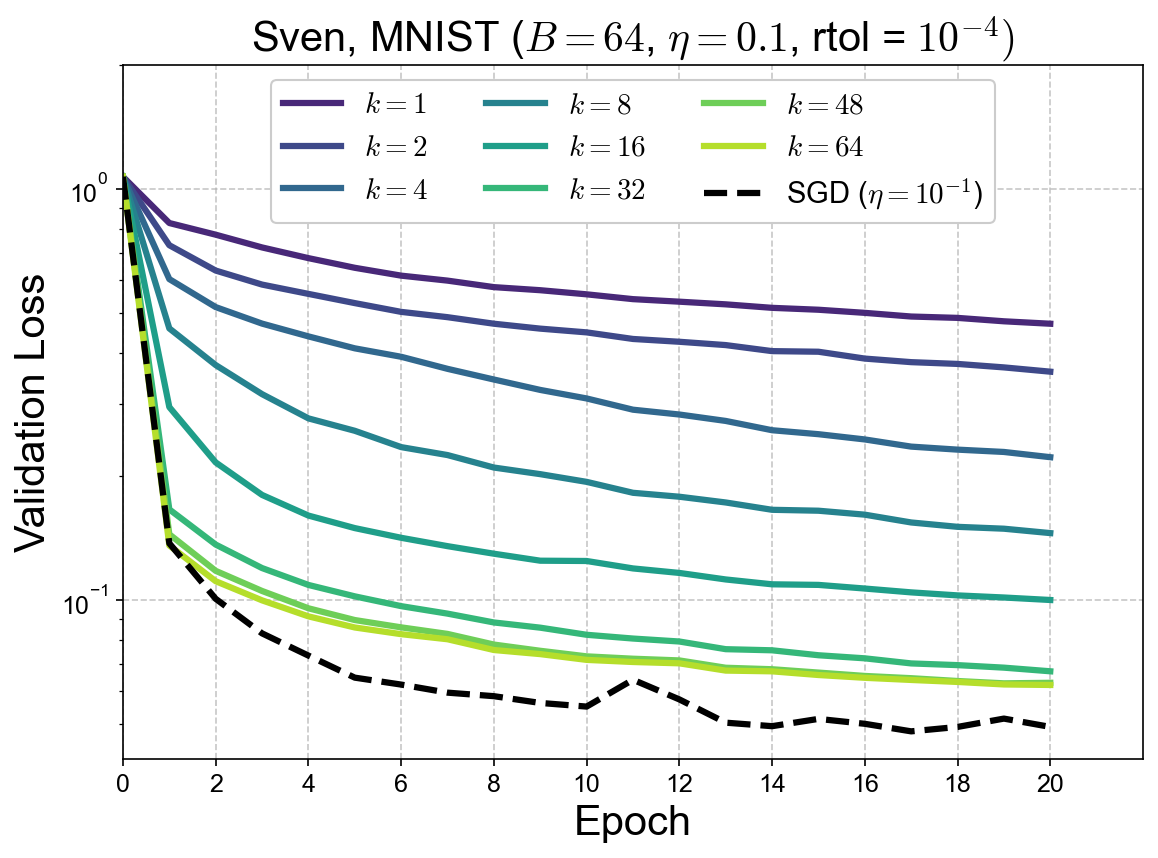

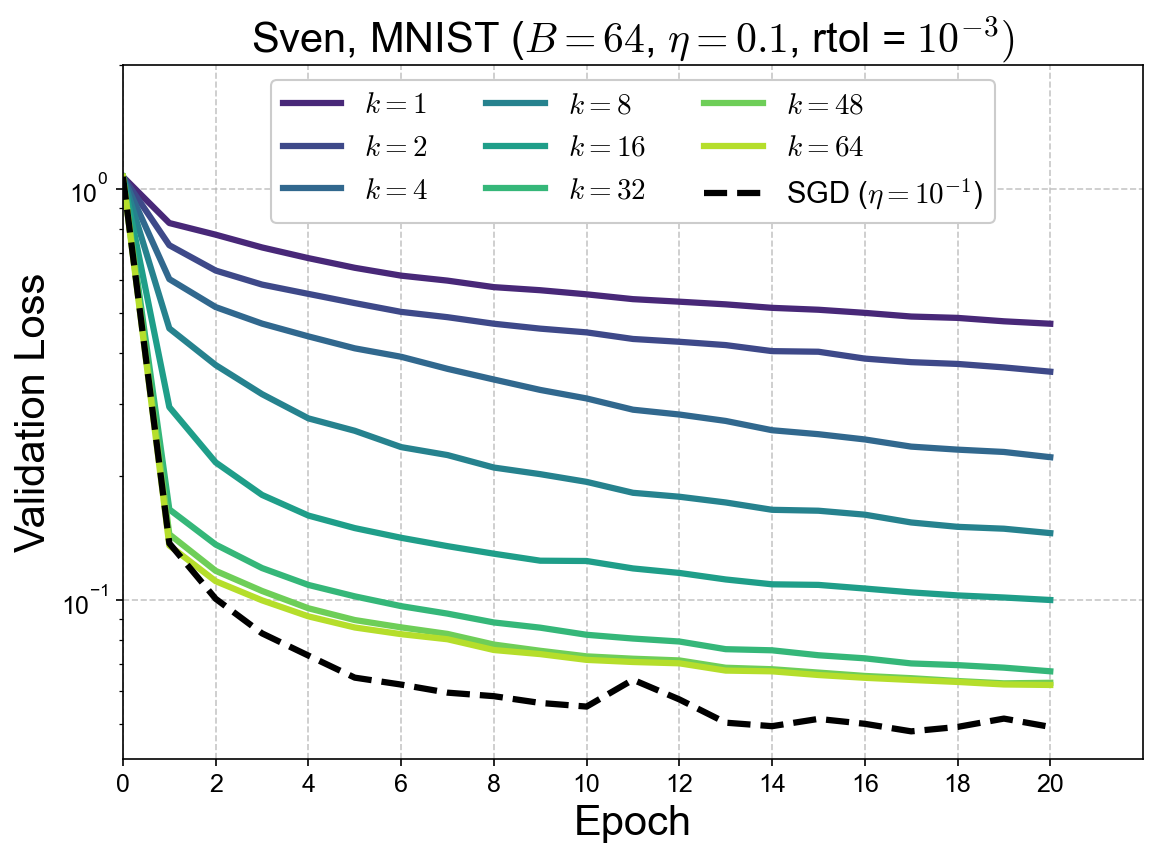

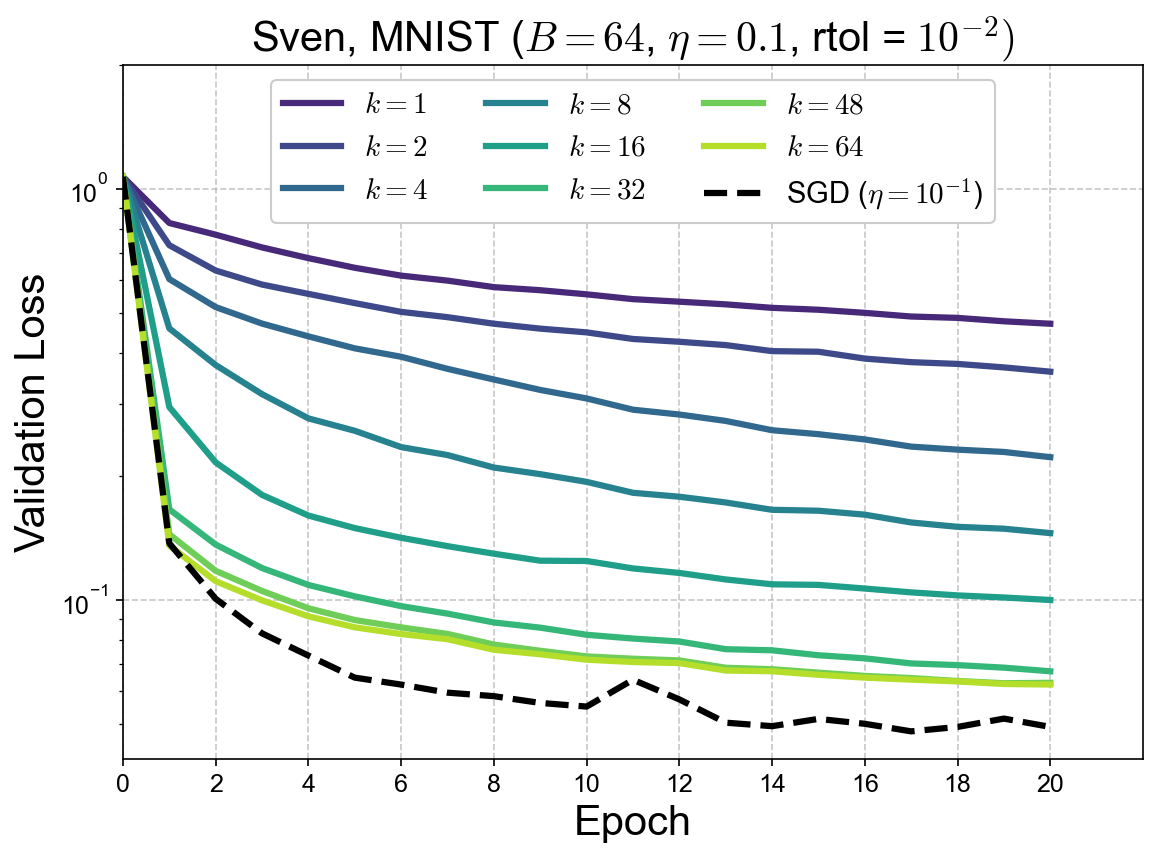

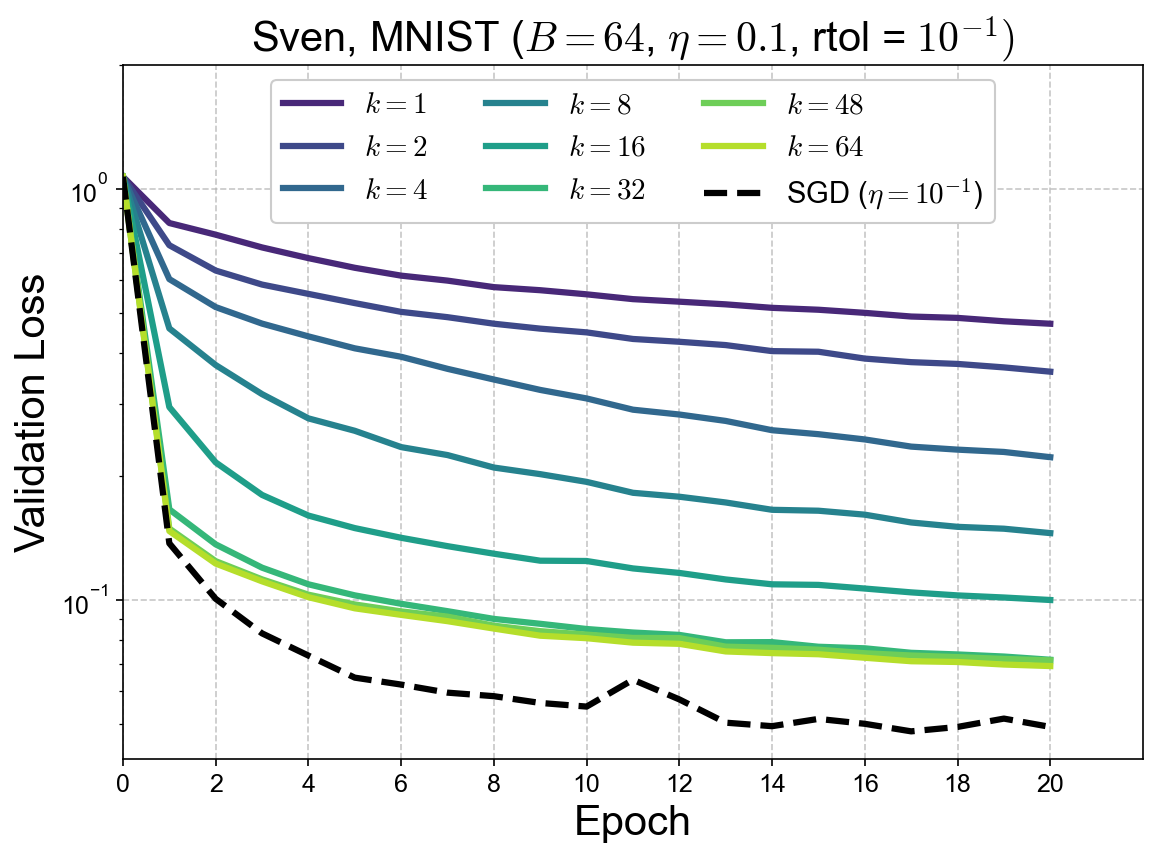

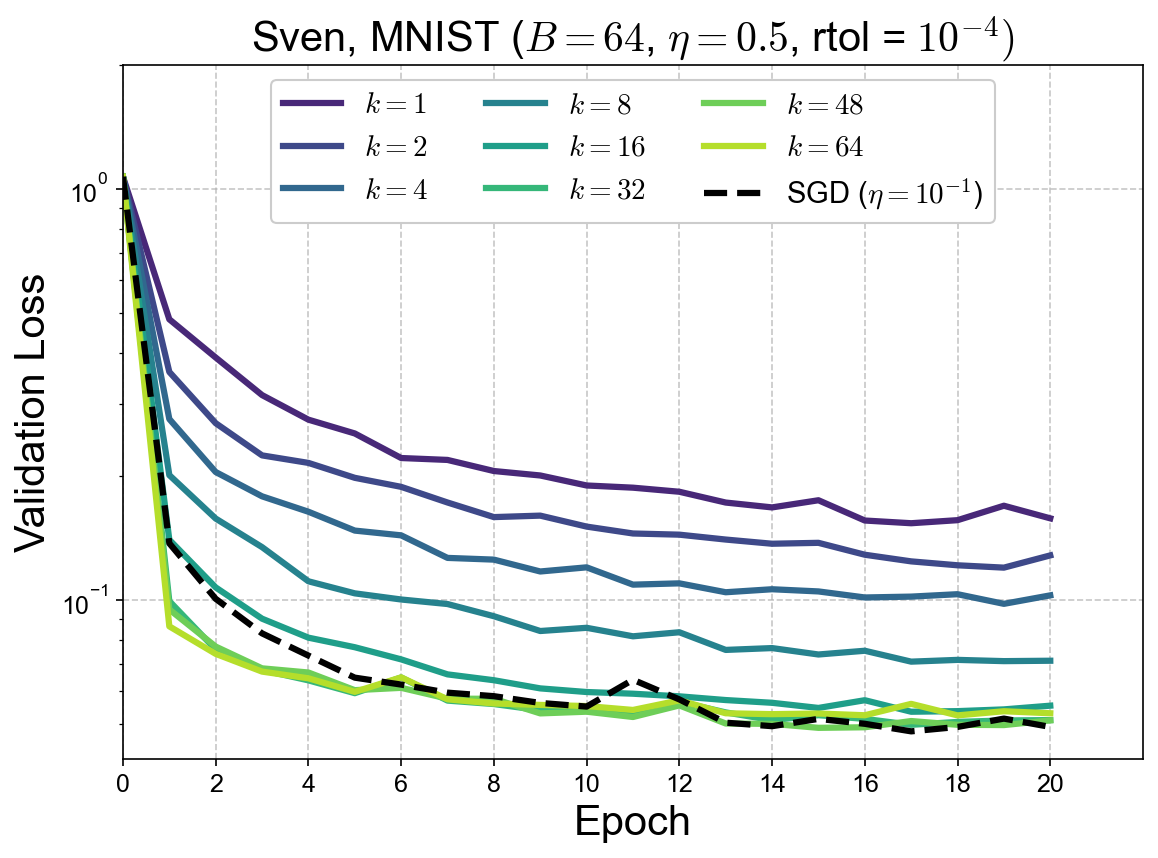

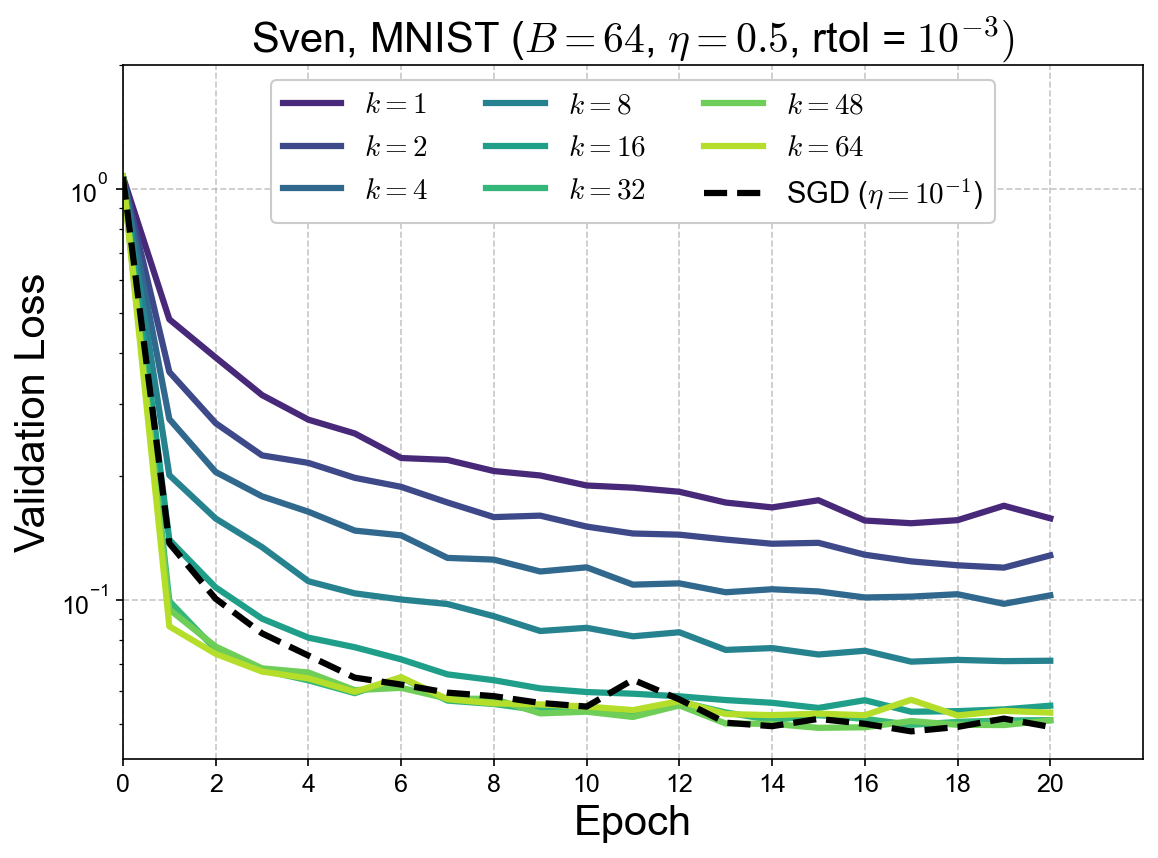

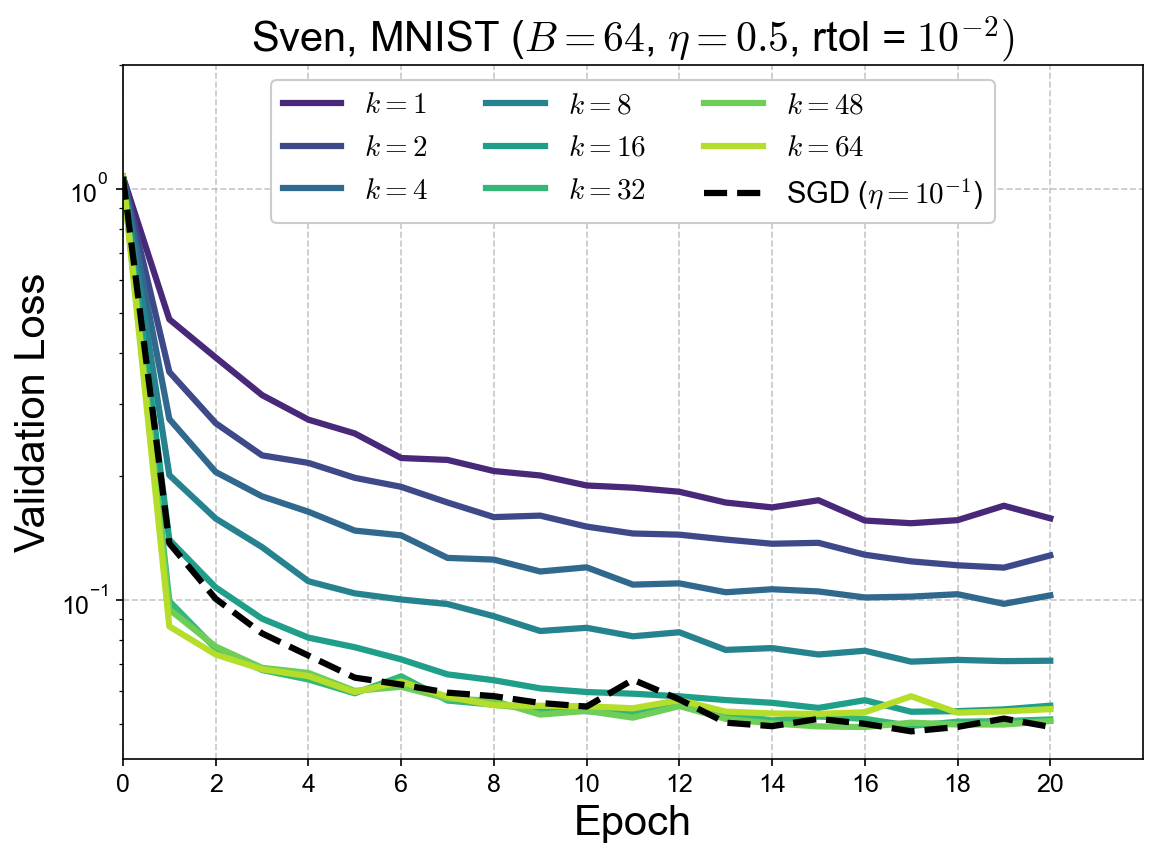

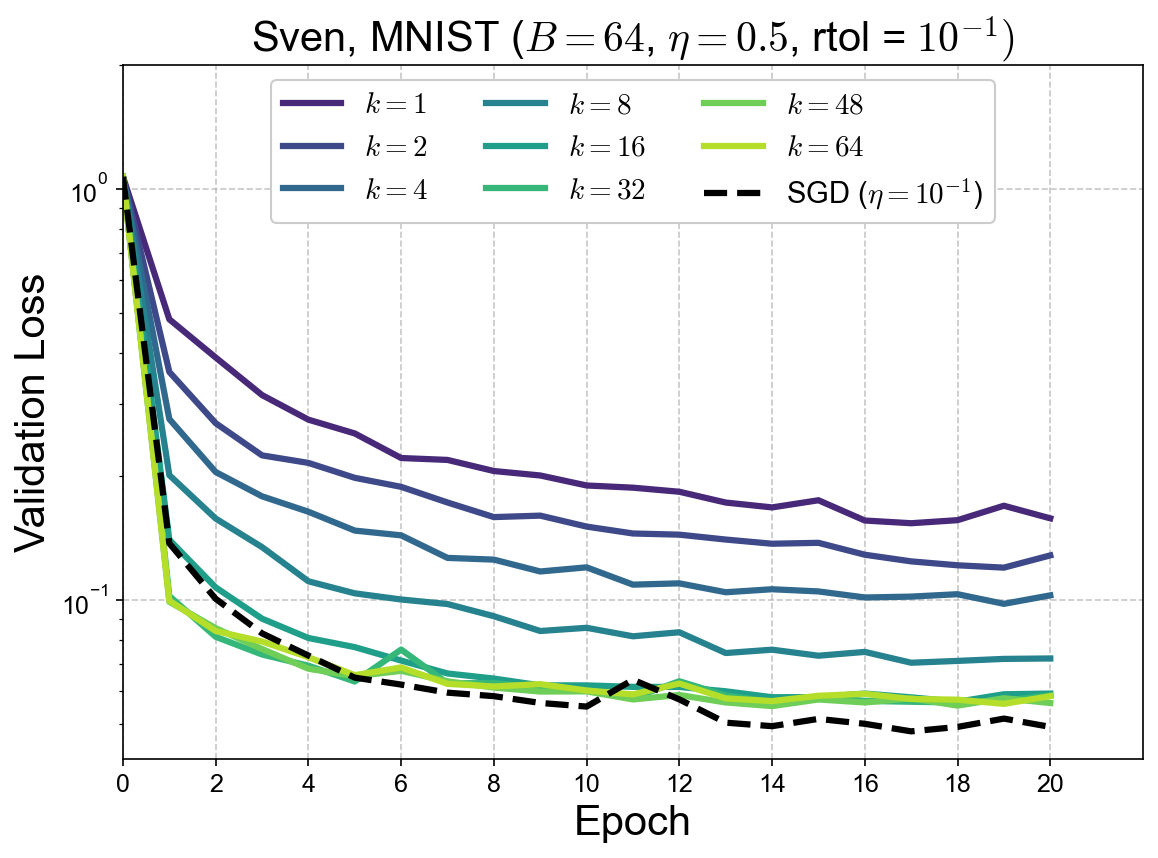

In [32]:
for LR in [0.05,0.1,0.5]:
    for RTOL in [1e-4,1e-3,1e-2,1e-1]:
        fig, ax = plt.subplots(figsize=(8, 6))
        df_sel = df_svd[(df_svd['batch_size'] == bs) & (df_svd['lr'] == LR) & (df_svd['rtol'] == RTOL)]
        k_values = sorted(df_sel['k'].unique())
        colors = sns.color_palette("viridis",n_colors=len(k_values))
        for i,k in enumerate(k_values):
            row = df_sel[df_sel['k'] == k]
            assert len(row) == 1, f"Expected exactly one run for k={k}, found {len(row)}"
            row = row.iloc[0]
            val_curve = get_loss_curve(row, 'val')
            epochs = np.arange(0, len(val_curve))
            ax.plot(epochs, val_curve, label=f"$k={int(k)}$", color=colors[i], linewidth=3)

        df_sgd = df_baseline[(df_baseline['batch_size'] == bs) & (df_baseline['optimizer'] == 'SGD')]
        best_sgd_row = df.loc[df_sgd['final_val_loss'].idxmin()]
        ax.plot(epochs, get_loss_curve(best_sgd_row, 'val'), label=f"SGD ($\eta={lr_labels[best_sgd_row['lr']]}$)", color='k', linestyle='--', linewidth=3)

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation Loss')
        ax.set_yscale('log')
        plt.legend(ncol=3,loc='upper center',frameon=True,framealpha=1)
        ax.set_title(f"Sven, MNIST ($B = {bs}$, $\eta={LR}$, rtol = ${lr_labels[RTOL]})$")
        plt.ylim([None,2])
        plt.xlim(0,n_epochs+1)
        plt.xticks(np.arange(0, n_epochs+1, max(1, n_epochs//10)))
        plt.grid(axis='both', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.savefig(PLOT_DIR / f"val_loss_k_comparison_bs{bs}_lr{LR}_rtol{RTOL}.pdf")
        plt.show()